# Exposure or Risk? Predicting Extreme Bicycle-Theft Density Hotspots from Cycle-Parking Infrastructure in London

## Preparation

- Github link: https://github.com/WanqiLiu1702/CASA0006-Data-Science-for-Spatial-Systems
- Word count: approximately 1,400, excluding code, tables and references.
- Runtime: about 8-9 minutes on a local Windows Jupyter environment (Memory 16 GB, CPU AMD Ryzen 7 6800H with Radeon Graphics).
- Coding environment: Python 3.12.10 in Jupyter Notebook 7.5.6; pandas 3.0.2, geopandas 1.1.3, scipy 1.17.1, scikit-learn 1.8.0, matplotlib 3.10.9.
- License: this notebook is made available under the [Creative Commons Attribution 4.0 license](https://creativecommons.org/licenses/by/4.0/).
- Data access: the notebook reads cached files first; if absent, it downloads the fixed coursework dataset from GitHub raw URLs.

## Table of contents

1. [Introduction](#Introduction)
2. [Research questions](#Research-questions)
3. [Data](#Data)
4. [Methodology](#Methodology)
5. [Results and discussion](#Results-and-discussion)
6. [Conclusion](#Conclusion)
7. [References](#References)

## Introduction
[[ go back to the top ]](#Table-of-contents)

Bicycle theft sits at the intersection of crime control and cycling policy. Promoting cycling requires parking capacity, yet concentrations of parked bicycles create the opportunity structures that routine activity and crime pattern theories identify as the substrate of property crime (Cohen and Felson, 1979; Brantingham and Brantingham, 1995). London makes this tension acute: theft is geographically concentrated in the same inner boroughs where parking provision is expanding.

Recent empirical work maps this spatial logic but stops short of operationalising it. Mburu and Helbich (2016) show that London bicycle theft tracks transport and land-use opportunities more than deprivation, but their model is descriptive. Problem-oriented policing guidance (Johnson et al., 2008) and intervention evidence from central London (Sidebottom et al., 2009) both presuppose the ability to identify priority locations in advance. Ito, Morgan and Lovelace (2023) frame cycle-parking investment as a portfolio problem, but treat parking as dependent rather than diagnostic.

This project turns that literature into a supervised geospatial machine-learning task. It asks whether cycle-parking infrastructure and town-centre context can predict extreme bicycle-theft-density hotspots across London LSOAs. The model predicts recorded theft-density concentration, not individual per-bike risk. Cycle parking is interpreted as an exposure signal, not causal evidence that parking creates theft.

## Research questions
[[ go back to the top ]](#Table-of-contents)

Main research question: Can cycle-parking infrastructure and town-centre context predict extreme bicycle-theft-density hotspots across London LSOAs?

1. How spatially concentrated is recorded bicycle theft across London LSOAs?
2. Do cycle-parking density and town-centre context provide useful predictive signal?
3. How much performance changes under stricter hotspot thresholds and borough-based spatial validation?
4. Can model output be operationalised into an exposure-risk portfolio for secure-parking or residual-risk investigation?

## Data
[[ go back to the top ]](#Table-of-contents)

The main dataset is MPS LSOA-level recorded crime from the London Datastore. The analysis selects `BICYCLE THEFT` and sums all detected monthly columns. LSOA 2021 boundaries provide area, centroids and borough groups. LSOA is used because it is the smallest reliable London-wide join geography for these data. TfL cycle-parking points provide public parking locations and capacity. GLA town-centre polygons measure activity-centre context. Fixed copies are read from GitHub raw URLs and cached locally; the MPS source is updated periodically, so this file fixes 25 inclusive columns from `202403` to `202603`.

The dependent variable is not raw theft count. Counts are converted to theft density per square kilometre because LSOAs differ in size; resident population is less appropriate for parked-bicycle exposure. The target is the top 10% of LSOAs by theft density, labelled extreme hotspots. This stricter top-decile target reflects limited intervention resources and creates a rare-event classification task. Sensitivity checks repeat modelling at top 25%, 20%, 15% and 10%.

Temporal alignment is imperfect: crime is summed across detected MPS months, while cycle parking and town centres are spatial snapshots. MPS rows match 3,914 LSOAs; the remaining 1,080 are retained as zero-record areas because the task is London-wide hotspot screening. Results are cross-sectional associations, not causal time-series estimates.

| Variable | Type | Role | Interpretation |
|---|---|---|---|
| `bike_theft_count` | numeric | source outcome | summed MPS bicycle-theft records |
| `bike_density_km2` | numeric | target basis | theft count divided by LSOA area |
| `extreme_hotspot` | binary | ML target | 1 if top 10% by theft density |
| `cycle_parking_capacity_km2` | numeric | predictor | parked-bicycle exposure proxy |
| `cycle_parking_locs_km2` | numeric | predictor | density of public parking locations |
| `town_centre_share` | numeric | predictor | share of LSOA covered by town centres |
| `town_centre_area_km2` | numeric | predictor | town-centre overlap area |
| `town_centre_pieces` | numeric | predictor | number of overlapping town-centre polygons |
| `x_km`, `y_km` | numeric | predictor | spatial location for broad geography |
| `lad22nm` | categorical | validation group | borough used only for GroupKFold |

### Data preparation code

The following cells set up the Python environment, load each dataset, clean key fields and construct the LSOA-level analysis table used by the models.

In [1]:
import os
import re
import zipfile
import urllib.request
import warnings
from pathlib import Path

osgeo_proj = Path(r"C:\OSGeo4W\share\proj")
if osgeo_proj.exists():
    os.environ["PROJ_LIB"] = str(osgeo_proj)

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.optimize import minimize
from scipy.special import expit
from scipy.stats import spearmanr
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.patheffects as pe

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GroupKFold, train_test_split, cross_validate
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)

URLS = {
    "mps_lsoa": "https://raw.githubusercontent.com/WanqiLiu1702/CASA0006-Data-Science-for-Spatial-Systems/main/data/mps_lsoa_recent.csv",
    "cycle_parking": "https://raw.githubusercontent.com/WanqiLiu1702/CASA0006-Data-Science-for-Spatial-Systems/main/data/tfl_cycle_parking.json",
    "town_centres": "https://raw.githubusercontent.com/WanqiLiu1702/CASA0006-Data-Science-for-Spatial-Systems/main/data/town_centres.geojson",
    "lsoa_zip": "https://raw.githubusercontent.com/WanqiLiu1702/CASA0006-Data-Science-for-Spatial-Systems/main/data/lsoa2021.zip",
}

def ensure_file(path, url):
    path = Path(path)
    if path.exists() and path.stat().st_size > 0:
        return path
    print(f"Downloading {path.name} ...")
    urllib.request.urlretrieve(url, path)
    return path

mps_path = ensure_file(DATA_DIR / "mps_lsoa_recent.csv", URLS["mps_lsoa"])
parking_path = ensure_file(DATA_DIR / "tfl_cycle_parking.json", URLS["cycle_parking"])
town_centres_path = ensure_file(DATA_DIR / "town_centres.geojson", URLS["town_centres"])

In [3]:
lsoa_dir = DATA_DIR / "lsoa2021" / "LB_shp"
if not list(lsoa_dir.glob("*.shp")):
    zip_path = ensure_file(DATA_DIR / "lsoa2021.zip", URLS["lsoa_zip"])
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(DATA_DIR / "lsoa2021")

shp_files = sorted(lsoa_dir.glob("*.shp"))
lsoa = pd.concat([gpd.read_file(p) for p in shp_files], ignore_index=True)
lsoa = gpd.GeoDataFrame(lsoa, geometry="geometry", crs=lsoa.crs).to_crs(27700)

lsoa["area_km2"] = lsoa.geometry.area / 1e6
centroids = lsoa.geometry.centroid
lsoa["x_km"] = centroids.x / 1000
lsoa["y_km"] = centroids.y / 1000
lsoa[["lsoa21cd", "lad22nm", "area_km2", "x_km", "y_km"]].head()

,lsoa21cd,lad22nm,area_km2,x_km,y_km
0,E01000011,Barking and Dagenham,0.091632,544.384248,184.738452
1,E01000046,Barking and Dagenham,0.155494,547.126437,184.089816
2,E01000051,Barking and Dagenham,0.066632,544.524194,183.764030
3,E01000077,Barking and Dagenham,0.173825,547.493123,185.555559
4,E01000083,Barking and Dagenham,0.179943,547.654943,185.993214


In [4]:
crime = pd.read_csv(mps_path)
month_cols = [c for c in crime.columns if re.fullmatch(r"20\d{4}", str(c))]

crime["row_total"] = crime[month_cols].sum(axis=1)
bike_counts = (
    crime.loc[crime["Minor Category"].str.upper().eq("BICYCLE THEFT")]
    .groupby("LSOA Code")["row_total"].sum()
    .rename("bike_theft_count")
    .reset_index()
)

lsoa = lsoa.merge(bike_counts, left_on="lsoa21cd", right_on="LSOA Code", how="left")
lsoa["bike_theft_count"] = lsoa["bike_theft_count"].fillna(0)
bike_counts.head()

,LSOA Code,bike_theft_count
0,E01000007,8
1,E01000008,2
2,E01000009,2
3,E01000011,2
4,E01000012,2


In [5]:
parking = gpd.read_file(parking_path)
if parking.crs is None:
    parking = parking.set_crs(4326, allow_override=True)
parking = parking.to_crs(27700)

capacity_col = next(
    (c for c in parking.columns if c.upper() in {"PRK_CPT", "CAPACITY"} or "CPT" in c.upper() or "CAP" in c.upper()),
    None,
)
parking["parking_capacity"] = pd.to_numeric(parking[capacity_col], errors="coerce").fillna(0) if capacity_col else 0

parking_join = gpd.sjoin(
    parking[["geometry", "parking_capacity"]],
    lsoa[["lsoa21cd", "geometry"]],
    how="left",
    predicate="within",
)
parking_lsoa = (
    parking_join.dropna(subset=["lsoa21cd"])
    .groupby("lsoa21cd")
    .agg(cycle_parking_locs=("parking_capacity", "size"),
         cycle_parking_capacity=("parking_capacity", "sum"))
    .reset_index()
)

lsoa = lsoa.merge(parking_lsoa, on="lsoa21cd", how="left")
lsoa[["cycle_parking_locs", "cycle_parking_capacity"]] = lsoa[["cycle_parking_locs", "cycle_parking_capacity"]].fillna(0)
parking_lsoa.head()

,lsoa21cd,cycle_parking_locs,cycle_parking_capacity
0,E01000001,11,96.0
1,E01000002,31,277.0
2,E01000003,11,44.0
3,E01000005,22,226.0
4,E01000007,6,64.0


In [6]:
centres = gpd.read_file(town_centres_path)
if centres.crs is None:
    centres = centres.set_crs(4326, allow_override=True)
centres = centres.to_crs(27700)
centres["town_centre_id"] = np.arange(len(centres))

intersections = gpd.overlay(
    lsoa[["lsoa21cd", "geometry"]],
    centres[["town_centre_id", "geometry"]],
    how="intersection",
)
intersections["town_centre_area_km2"] = intersections.geometry.area / 1e6

town_lsoa = (
    intersections.groupby("lsoa21cd")
    .agg(town_centre_area_km2=("town_centre_area_km2", "sum"),
         town_centre_pieces=("town_centre_id", "nunique"))
    .reset_index()
)

analysis = lsoa.merge(town_lsoa, on="lsoa21cd", how="left")
analysis[["town_centre_area_km2", "town_centre_pieces"]] = analysis[["town_centre_area_km2", "town_centre_pieces"]].fillna(0)
town_lsoa.head()

,lsoa21cd,town_centre_area_km2,town_centre_pieces
0,E01000001,0.001266,1
1,E01000002,0.035261,3
2,E01000003,0.005802,1
3,E01000007,0.056252,1
4,E01000009,0.012975,1


In [7]:
analysis["bike_density_km2"] = analysis["bike_theft_count"] / analysis["area_km2"].replace(0, np.nan)
analysis["cycle_parking_locs_km2"] = analysis["cycle_parking_locs"] / analysis["area_km2"].replace(0, np.nan)
analysis["cycle_parking_capacity_km2"] = analysis["cycle_parking_capacity"] / analysis["area_km2"].replace(0, np.nan)
analysis["town_centre_share"] = (analysis["town_centre_area_km2"] / analysis["area_km2"]).clip(upper=1)
analysis = analysis.replace([np.inf, -np.inf], np.nan).fillna(0)

hotspot_threshold = analysis["bike_density_km2"].quantile(0.90)
analysis["extreme_hotspot"] = (analysis["bike_density_km2"] >= hotspot_threshold).astype(int)

overview = pd.DataFrame({
    "item": [
        "LSOAs",
        "MPS monthly columns",
        "MPS month range",
        "cycle parking points",
        "cycle capacity field",
        "town centre polygons",
        "extreme hotspot threshold",
    ],
    "value": [
        len(analysis),
        len(month_cols),
        f"{min(month_cols)}-{max(month_cols)}",
        len(parking),
        capacity_col,
        len(centres),
        round(hotspot_threshold, 2),
    ],
})
overview

,item,value
0,LSOAs,4994
1,MPS monthly columns,25
2,MPS month range,202403-202603
3,cycle parking points,23758
4,cycle capacity field,PRK_CPT
5,town centre polygons,234
6,extreme hotspot threshold,101.39


In [8]:
snapshot_cols = [
    "lsoa21cd", "lad22nm", "area_km2", "x_km", "y_km",
    "bike_theft_count", "bike_density_km2", "extreme_hotspot",
    "cycle_parking_locs", "cycle_parking_capacity",
    "cycle_parking_locs_km2", "cycle_parking_capacity_km2",
    "town_centre_area_km2", "town_centre_share", "town_centre_pieces",
]
snapshot_path = DATA_DIR / "analysis_lsoa_snapshot_v2.csv"
analysis[snapshot_cols].to_csv(snapshot_path, index=False)

qa = pd.DataFrame({
    "Check": [
        "MPS monthly columns",
        "MPS detected month range",
        "Bicycle-theft LSOA codes matched",
        "Parking points joined to London LSOAs",
        "Town-centre overlay pieces",
        "Invalid LSOA geometries",
        "Invalid town-centre geometries",
        "Final missing feature values",
        "Processed snapshot",
    ],
    "Result": [
        len(month_cols),
        f"{min(month_cols)}-{max(month_cols)}",
        f"{bike_counts['LSOA Code'].isin(lsoa['lsoa21cd']).sum()}/{len(bike_counts)}",
        f"{parking_join['lsoa21cd'].notna().sum()}/{len(parking)}",
        len(intersections),
        int((~lsoa.geometry.is_valid).sum()),
        int((~centres.geometry.is_valid).sum()),
        int(analysis[snapshot_cols].isna().sum().sum()),
        snapshot_path.as_posix(),
    ],
})
display(qa)

,Check,Result
0,MPS monthly columns,25
1,MPS detected month range,202403-202603
2,Bicycle-theft LSOA codes matched,3914/3914
3,Parking points joined to London LSOAs,23758/23758
4,Town-centre overlay pieces,1479
5,Invalid LSOA geometries,0
6,Invalid town-centre geometries,0
7,Final missing feature values,0
8,Processed snapshot,D:/CASA-USS/DS/data/analysis_lsoa_snapshot_v2.csv


In [9]:
borough_context = analysis.dissolve(by="lad22nm", as_index=False)[["lad22nm", "geometry"]]
label_boroughs = [
    "Westminster", "Camden", "Hackney", "Islington", "Southwark",
    "Tower Hamlets", "Lambeth", "City of London"
]
reference_borough_text = "\n".join([
    "Reference boroughs:",
    "Westminster",
    "Camden",
    "Hackney",
    "Islington",
    "Southwark",
    "Tower Hamlets",
    "Lambeth",
    "City of London",
])
reference_borough_inline = (
    "Reference boroughs: Westminster | Camden | Hackney | Islington | "
    "Southwark | Tower Hamlets | Lambeth | City of London"
)
reference_borough_6b = (
    "Reference boroughs: Westminster | Camden | Hackney | Islington\n"
    "Southwark | Tower Hamlets | Lambeth | City of London"
)
portfolio_key_areas = (
    "Key secure-parking boroughs: Hackney | Southwark | Westminster | "
    "Tower Hamlets | Islington"
)

def add_borough_context(ax, north=False, scale=False, north_xy=(0.93, 0.92), north_text=(0.93, 0.78), scale_xy=(0.07, 0.06)):
    borough_context.boundary.plot(ax=ax, color="#3f3f3f", linewidth=0.25, alpha=0.55)
    if north:
        ax.annotate(
            "N",
            xy=north_xy,
            xytext=north_text,
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=8,
            arrowprops=dict(arrowstyle="-|>", lw=1.1, color="#222222"),
        )
    if scale:
        xmin, ymin, xmax, ymax = analysis.total_bounds
        length_m = 10000
        x0 = xmin + scale_xy[0] * (xmax - xmin)
        y0 = ymin + scale_xy[1] * (ymax - ymin)
        ax.plot([x0, x0 + length_m], [y0, y0], color="#222222", lw=1.5)
        ax.plot([x0, x0], [y0 - 800, y0 + 800], color="#222222", lw=1)
        ax.plot([x0 + length_m, x0 + length_m], [y0 - 800, y0 + 800], color="#222222", lw=1)
        ax.text(x0 + length_m / 2, y0 + 1800, "10 km", ha="center", va="bottom", fontsize=6.5, color="#222222")

def note_axis(ax, lines, title=None):
    ax.axis("off")
    y = 0.98
    if title:
        ax.text(0, y, title, ha="left", va="top", fontsize=9.5, fontweight="bold")
        y -= 0.11
    ax.text(0, y, "\n".join(lines), ha="left", va="top", fontsize=8.2, linespacing=1.45, color="#222222")

## Methodology
[[ go back to the top ]](#Table-of-contents)

The analysis uses three core methods: exploratory spatial analysis, logistic regression and random forest classification. Spatial features are engineered in British National Grid (EPSG:27700). EDA maps theft density and exposure and measures rank associations using Spearman correlation. Logistic regression is an interpretable linear baseline; random forest captures non-linear feature interactions. Coordinates absorb broad inner-outer spatial trend; borough names are used only for group-aware splitting. Tree complexity is controlled through leaf-size settings because the aim is robust hotspot ranking under spatial validation. Class weights address imbalance, and average precision is reported because accuracy is misleading when only 10% of areas are hotspots.

Model validation and interpretation are used to assess robustness, transferability and substantive meaning rather than to introduce separate predictive targets. Feature ablation, threshold sensitivity, borough GroupKFold and coordinate-grid spatial-block GroupKFold test whether performance survives different feature sets, hotspot definitions and spatial partitions. Interpretation uses permutation importance and partial dependence because impurity-based importance can be biased toward variables with more possible split points (Strobl et al., 2007). A lift curve and out-of-fold residual diagnostic translate prediction into intervention value.

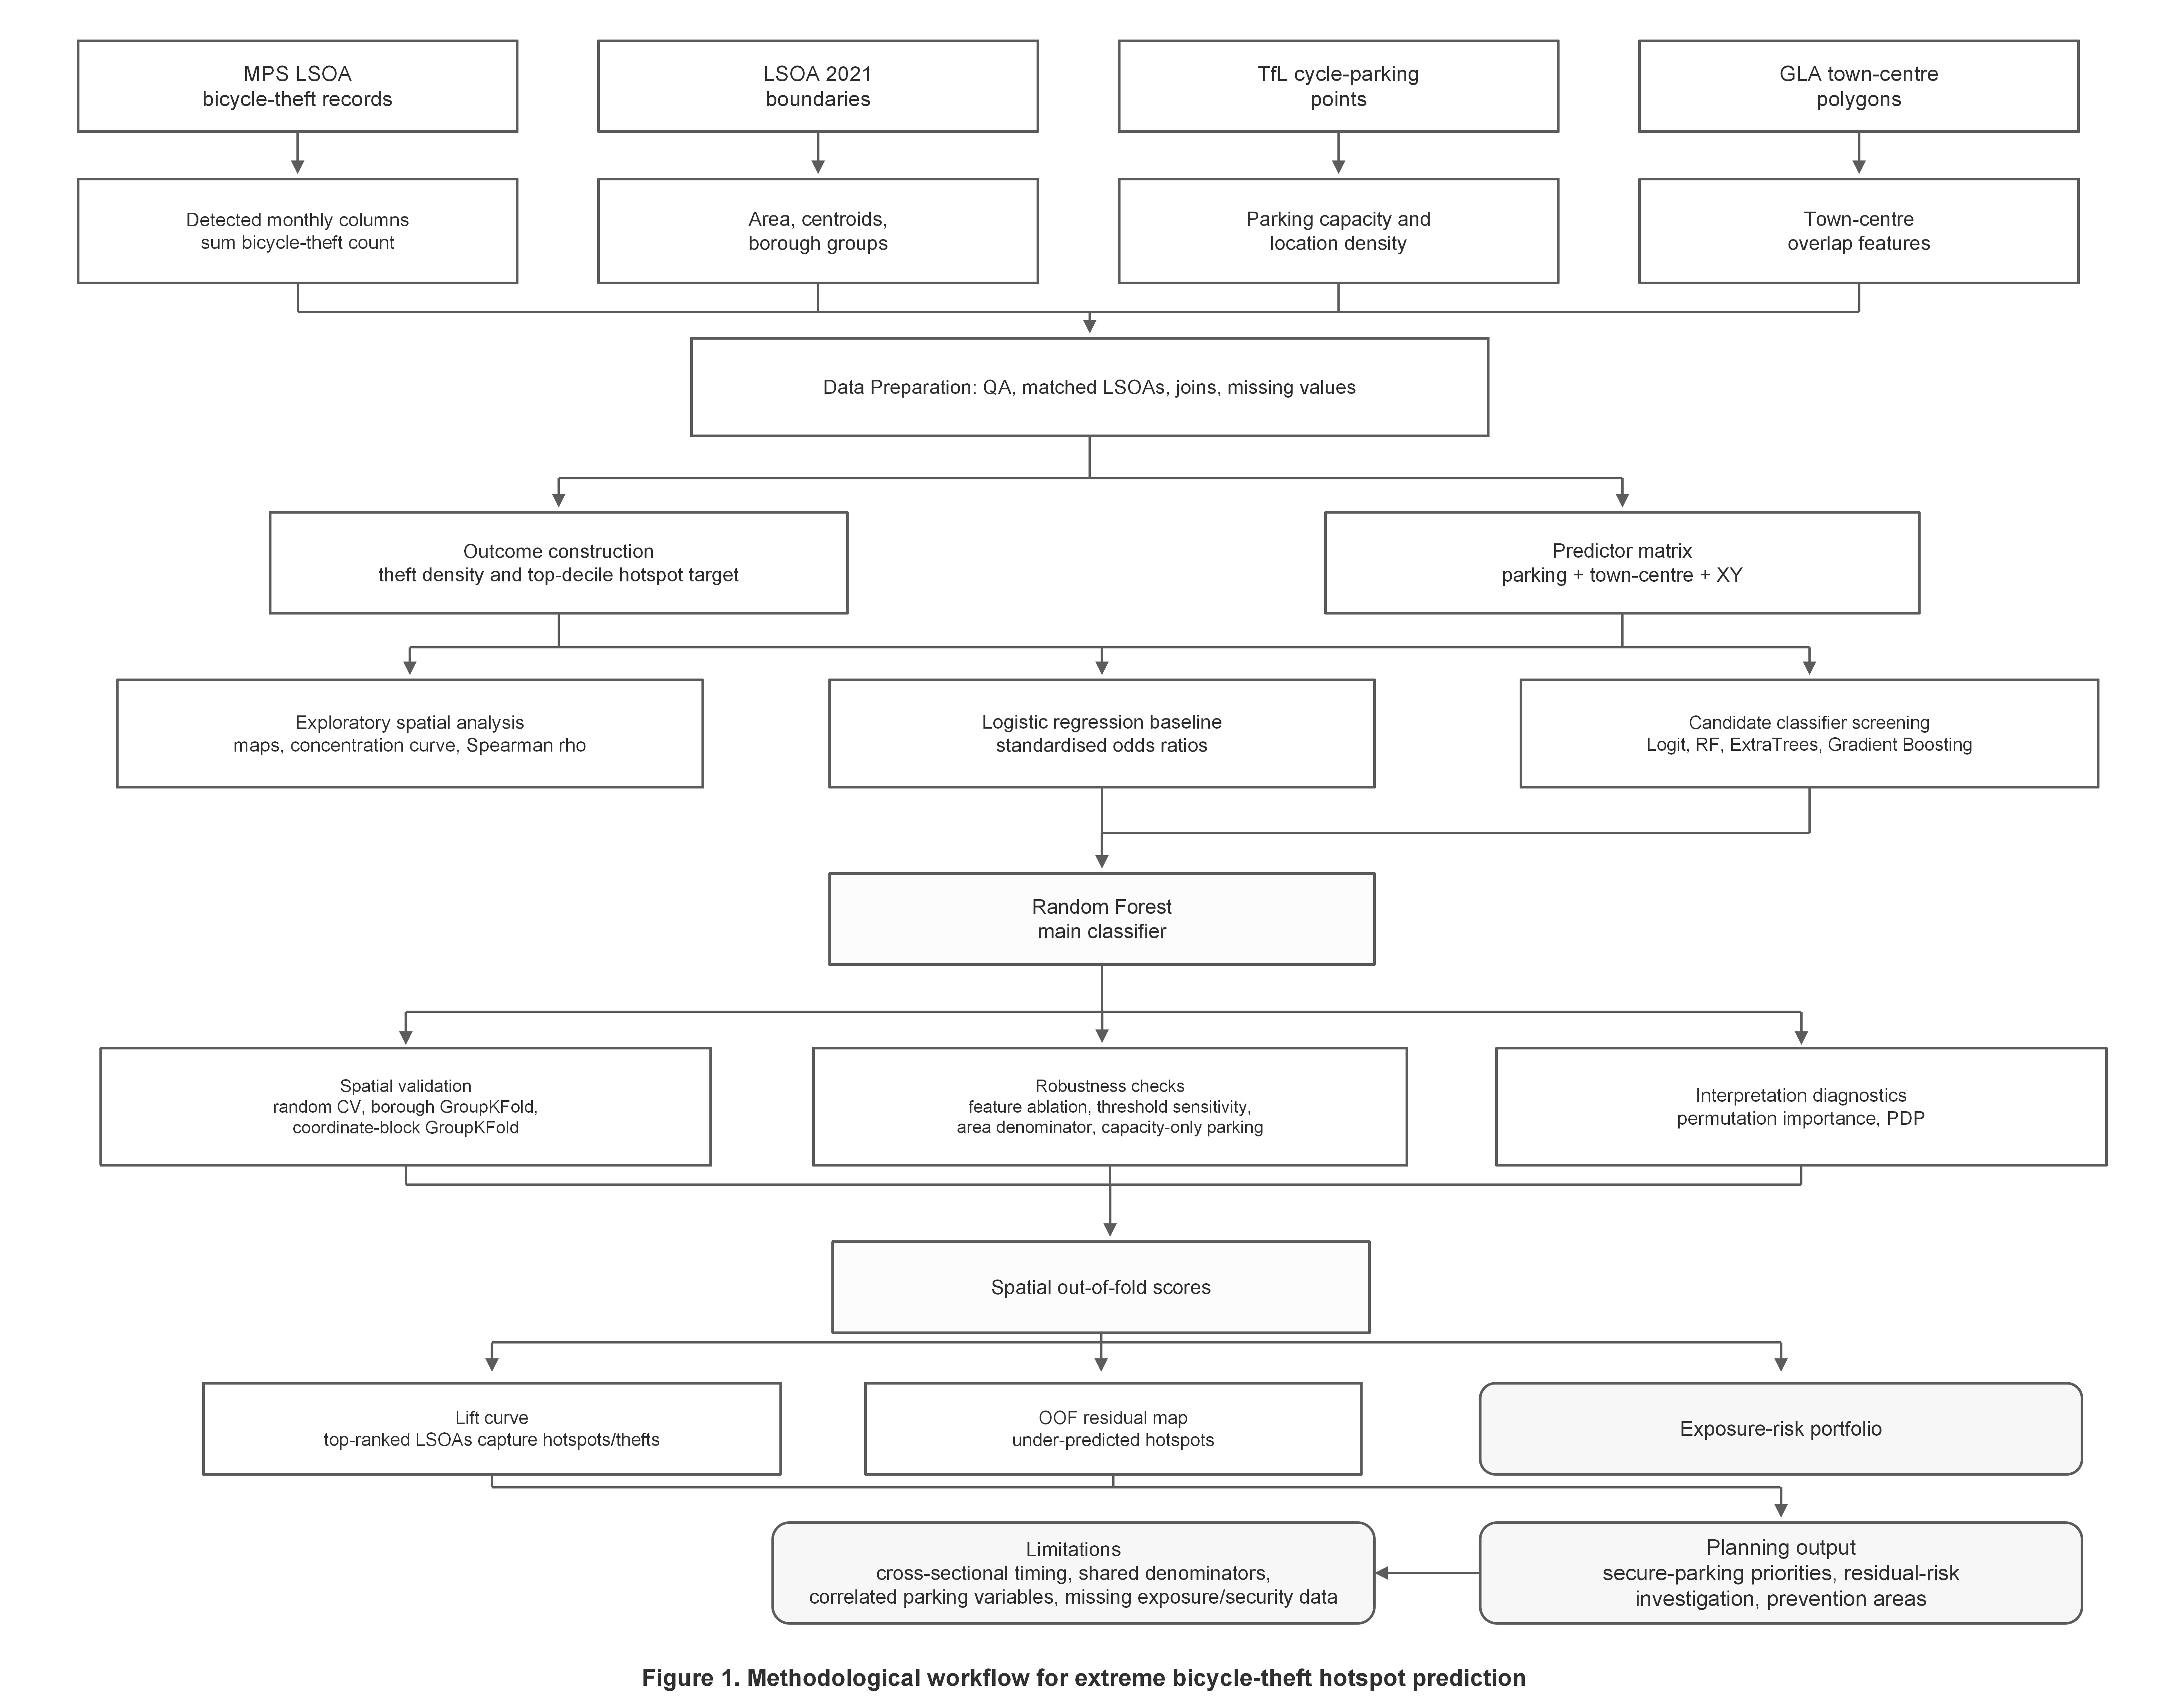

## Results and discussion
[[ go back to the top ]](#Table-of-contents)

In [10]:
def gini(values):
    x = np.sort(np.asarray(values, dtype=float))
    if np.all(x == 0):
        return 0
    n = len(x)
    return (2 * np.sum((np.arange(1, n + 1) * x)) / (n * np.sum(x))) - ((n + 1) / n)

summary_vars = {
    "Theft count": "bike_theft_count",
    "Theft density": "bike_density_km2",
    "Parking capacity density": "cycle_parking_capacity_km2",
    "Parking location density": "cycle_parking_locs_km2",
    "Town-centre share": "town_centre_share",
}
desc_rows = []
for label, col in summary_vars.items():
    s = analysis[col]
    desc_rows.append({
        "Variable": label,
        "Mean": s.mean(),
        "Median": s.median(),
        "P90": s.quantile(0.90),
        "Max": s.max(),
    })
desc = pd.DataFrame(desc_rows)
display(desc.round(2))

top10_share = analysis.loc[analysis["extreme_hotspot"].eq(1), "bike_theft_count"].sum() / analysis["bike_theft_count"].sum()
concentration = pd.DataFrame({
    "Measure": ["Gini of theft density", "Thefts in top-decile LSOAs", "Extreme hotspot prevalence"],
    "Value": [gini(analysis["bike_density_km2"]), top10_share, analysis["extreme_hotspot"].mean()]
})
display(concentration.round(3))

count_threshold = analysis["bike_theft_count"].quantile(0.90)
analysis["count_hotspot"] = analysis["bike_theft_count"] >= count_threshold
target_overlap = (analysis["extreme_hotspot"].eq(1) & analysis["count_hotspot"]).sum() / analysis["extreme_hotspot"].sum()
print(f"Target sensitivity check: {target_overlap:.1%} of top-density hotspots are also top-count hotspots.")
print(f"Count hotspot threshold: {count_threshold:.0f} thefts; density hotspot threshold: {hotspot_threshold:.2f} thefts/km2.")

corr_features = {
    "Parking capacity density": "cycle_parking_capacity_km2",
    "Parking location density": "cycle_parking_locs_km2",
    "Town-centre share": "town_centre_share",
    "Town-centre area": "town_centre_area_km2",
    "X coordinate": "x_km",
    "Y coordinate": "y_km",
}
corr = []
for label, feature in corr_features.items():
    rho, p = spearmanr(analysis["bike_density_km2"], analysis[feature])
    corr.append({"Feature": label, "rho": rho, "p": p})
display(pd.DataFrame(corr).sort_values("rho", ascending=False).round(3))

parking_rho, _ = spearmanr(analysis["cycle_parking_capacity_km2"], analysis["cycle_parking_locs_km2"])
print(f"Parking capacity-location Spearman rho: {parking_rho:.3f}; logit is used as a predictive baseline, not for isolated coefficient inference.")

,Variable,Mean,Median,P90,Max
0,Theft count,5.75,2.00,13.00,211.00
1,Theft density,37.34,11.12,101.39,1214.74
2,Parking capacity density,176.17,45.54,534.51,3541.56
3,Parking location density,30.86,7.98,91.67,604.96
4,Town-centre share,0.04,0.00,0.13,1.00


,Measure,Value
0,Gini of theft density,0.713
1,Thefts in top-decile LSOAs,0.457
2,Extreme hotspot prevalence,0.100


Target sensitivity check: 72.4% of top-density hotspots are also top-count hotspots.
Count hotspot threshold: 13 thefts; density hotspot threshold: 101.39 thefts/km2.


,Feature,rho,p
1,Parking location density,0.680,0.000
0,Parking capacity density,0.678,0.000
2,Town-centre share,0.344,0.000
3,Town-centre area,0.330,0.000
5,Y coordinate,0.001,0.941
4,X coordinate,-0.078,0.000


Parking capacity-location Spearman rho: 0.973; logit is used as a predictive baseline, not for isolated coefficient inference.


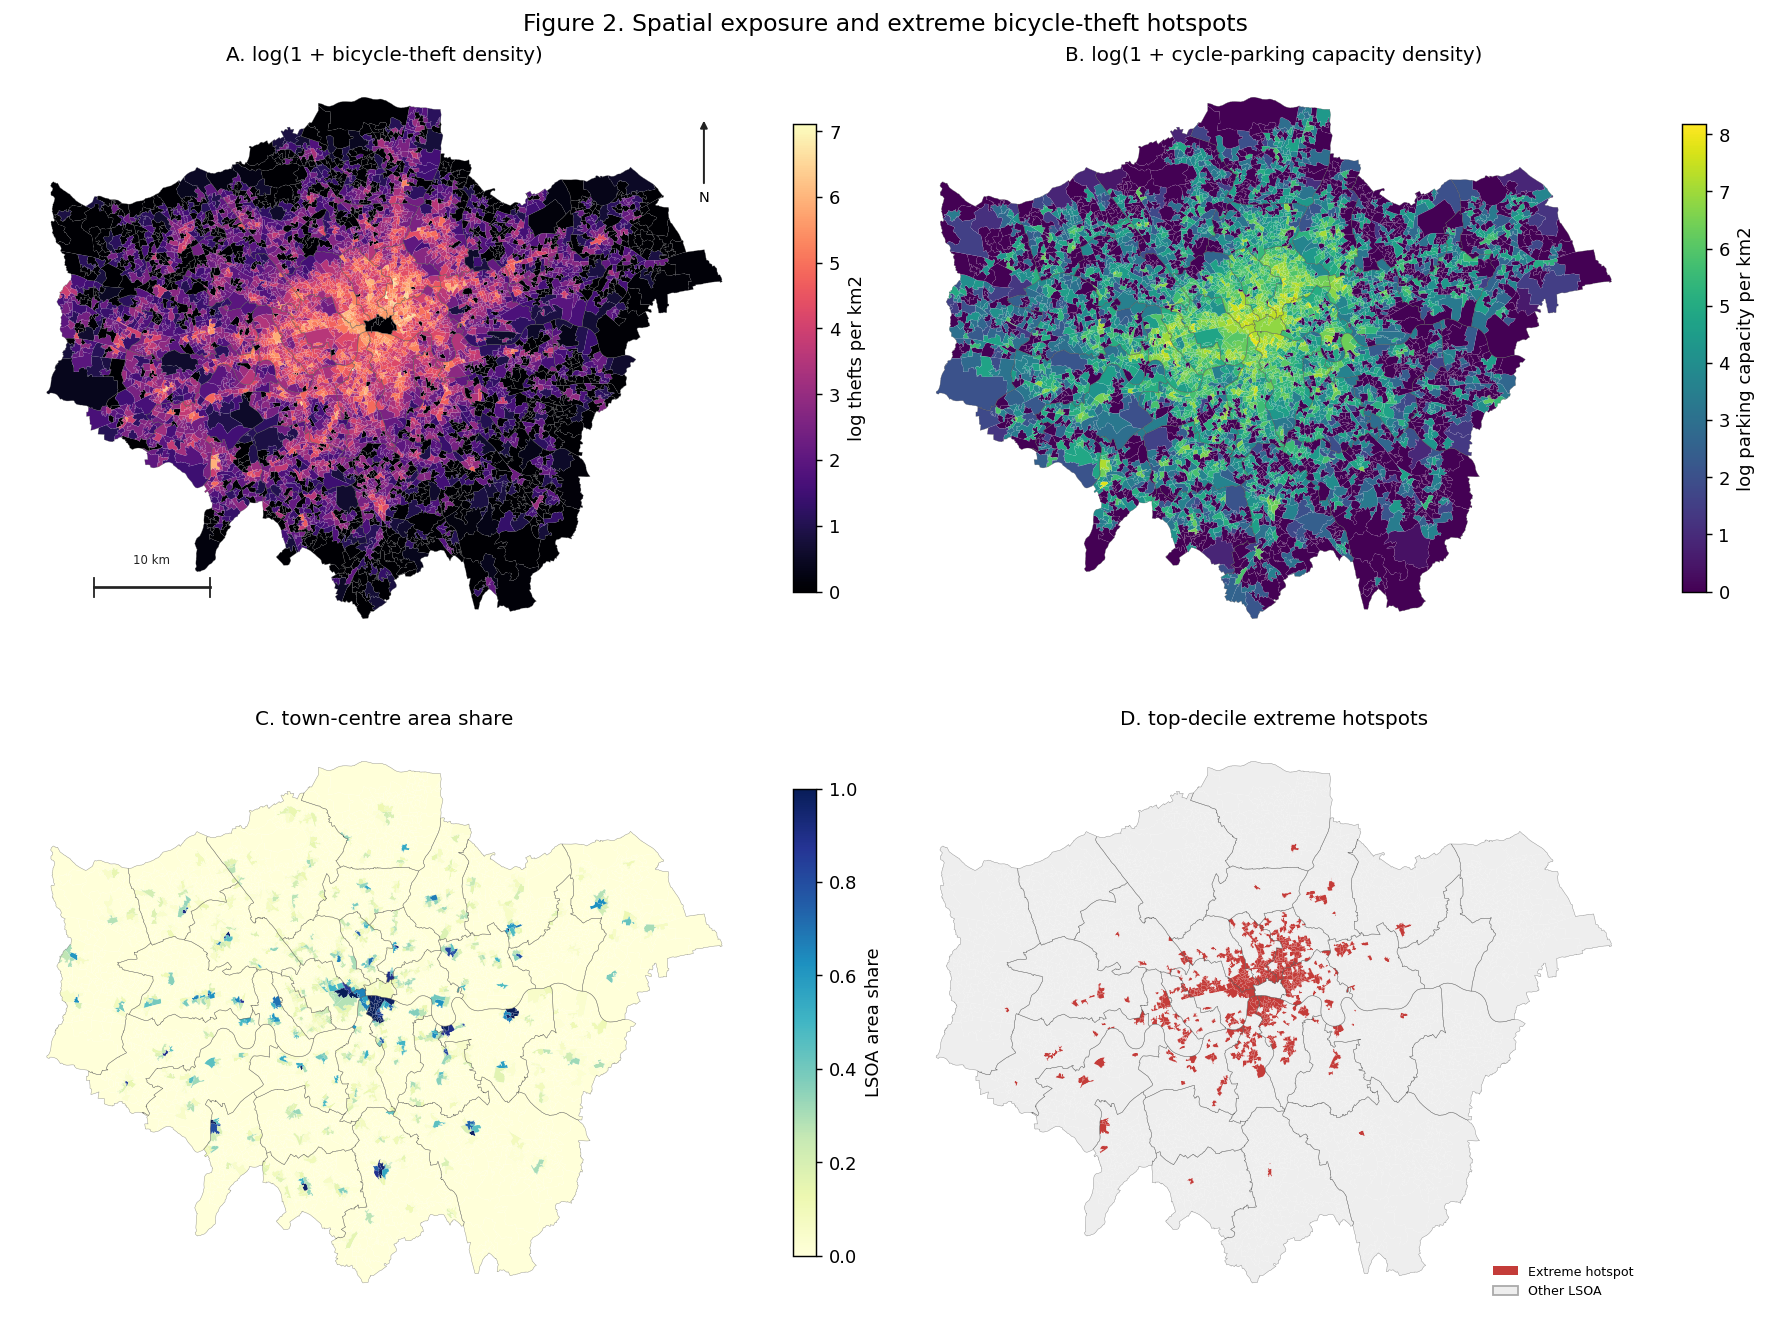

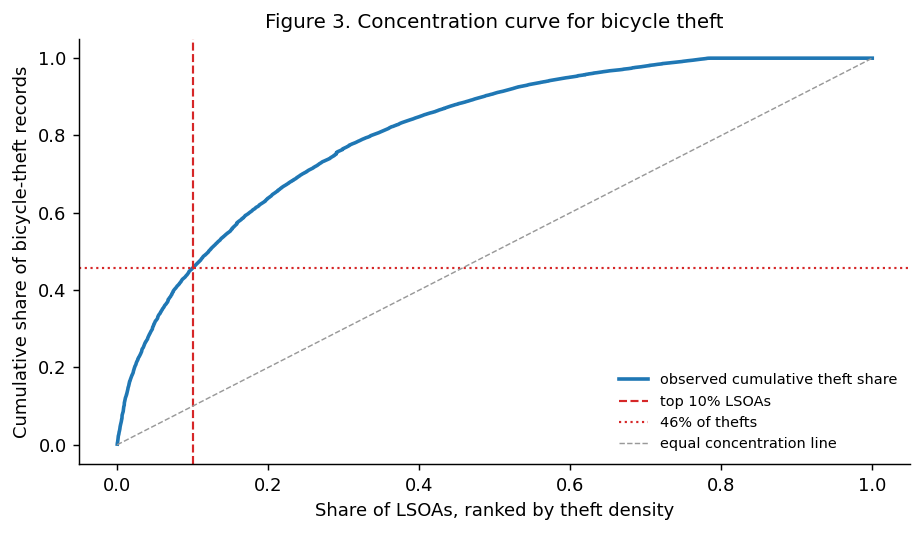

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 10.2), constrained_layout=True)
plot_data = analysis.copy()
plot_data["log_theft_density"] = np.log1p(plot_data["bike_density_km2"])
plot_data["log_parking_density"] = np.log1p(plot_data["cycle_parking_capacity_km2"])

plot_data.plot(
    column="log_theft_density",
    cmap="magma",
    linewidth=0.02,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "log thefts per km2", "shrink": 0.72},
    ax=axes[0, 0],
)
add_borough_context(axes[0, 0], north=True, scale=True)
axes[0, 0].set_title("A. log(1 + bicycle-theft density)")
plot_data.plot(
    column="log_parking_density",
    cmap="viridis",
    linewidth=0.02,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "log parking capacity per km2", "shrink": 0.72},
    ax=axes[0, 1],
)
add_borough_context(axes[0, 1])
axes[0, 1].set_title("B. log(1 + cycle-parking capacity density)")
plot_data.plot(
    column="town_centre_share",
    cmap="YlGnBu",
    linewidth=0.02,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "LSOA area share", "shrink": 0.72},
    ax=axes[1, 0],
)
add_borough_context(axes[1, 0])
axes[1, 0].set_title("C. town-centre area share")
plot_data.plot(color=plot_data["extreme_hotspot"].map({0: "#eeeeee", 1: "#c43c39"}), linewidth=0.02, edgecolor="white", ax=axes[1, 1])
add_borough_context(axes[1, 1])
axes[1, 1].set_title("D. top-decile extreme hotspots")
axes[1, 1].legend(
    handles=[Patch(facecolor="#c43c39", label="Extreme hotspot"), Patch(facecolor="#eeeeee", edgecolor="#aaaaaa", label="Other LSOA")],
    frameon=False,
    fontsize=7,
    loc="lower right",
)
for ax in axes.ravel():
    ax.set_axis_off()
plt.suptitle("Figure 2. Spatial exposure and extreme bicycle-theft hotspots", y=1.01, fontsize=13)
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ordered = analysis.sort_values("bike_density_km2", ascending=False)
cumulative = ordered["bike_theft_count"].cumsum() / ordered["bike_theft_count"].sum()
area_share = np.arange(1, len(ordered) + 1) / len(ordered)
ax.plot(area_share, cumulative, color="#1f77b4", lw=2, label="observed cumulative theft share")
ax.axvline(0.10, color="#d62728", ls="--", lw=1.2, label="top 10% LSOAs")
ax.axhline(top10_share, color="#d62728", ls=":", lw=1.2, label=f"{top10_share:.0%} of thefts")
ax.plot([0, 1], [0, 1], color="#999999", lw=0.8, ls="--", label="equal concentration line")
ax.set_xlabel("Share of LSOAs, ranked by theft density")
ax.set_ylabel("Cumulative share of bicycle-theft records")
ax.set_title("Figure 3. Concentration curve for bicycle theft")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

Figure 2 shows that extreme hotspots cluster in inner and activity-intensive London, but are not identical to town centres. The dark areas in the theft-density panel are low-density LSOAs on the `magma` colour ramp, not missing data. Reference boroughs for orientation are Westminster, Camden, Hackney, Islington, Southwark, Tower Hamlets, Lambeth and the City of London. Figure 3 confirms high concentration: top-decile density LSOAs contain a disproportionate theft share. The density-versus-count overlap is partial, so density captures small-area central hotspots that raw counts would partly miss. However, density outcomes and density predictors share area as a denominator, so robustness checks below test whether the result is only an area artefact.

In [12]:
feature_sets = {
    "town-centre only": ["town_centre_share", "town_centre_area_km2", "town_centre_pieces"],
    "cycle-parking only": ["cycle_parking_locs_km2", "cycle_parking_capacity_km2"],
    "parking + town-centre": ["cycle_parking_locs_km2", "cycle_parking_capacity_km2", "town_centre_share", "town_centre_area_km2", "town_centre_pieces"],
    "parking + town-centre + xy": ["x_km", "y_km", "cycle_parking_locs_km2", "cycle_parking_capacity_km2", "town_centre_share", "town_centre_area_km2", "town_centre_pieces"],
}
final_features = feature_sets["parking + town-centre + xy"]
y = analysis["extreme_hotspot"].astype(int)
groups = analysis["lad22nm"]
x_block = pd.qcut(analysis["x_km"], q=5, labels=False, duplicates="drop").astype(str)
y_block = pd.qcut(analysis["y_km"], q=5, labels=False, duplicates="drop").astype(str)
analysis["spatial_block"] = x_block + "_" + y_block
spatial_groups = analysis["spatial_block"]

In [13]:
def make_models():
    return {
        "Logistic regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
        ]),
        "Random forest": RandomForestClassifier(
            n_estimators=160,
            min_samples_leaf=8,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=1
        )
    }

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "accuracy": "accuracy"
}

def cv_row(model_name, model, X, y, cv, validation, groups=None):
    scores = cross_validate(model, X, y, cv=cv, groups=groups, scoring=scoring, n_jobs=1)
    row = {"validation": validation, "model": model_name}
    for metric in scoring:
        row[metric] = scores[f"test_{metric}"].mean()
    return row

In [14]:
X_final = analysis[final_features].replace([np.inf, -np.inf], np.nan).fillna(0)
model_rows = []
for name, model in make_models().items():
    model_rows.append(cv_row(name, model, X_final, y, StratifiedKFold(n_splits=5, shuffle=True, random_state=42), "random stratified CV"))
    model_rows.append(cv_row(name, model, X_final, y, GroupKFold(n_splits=5), "borough GroupKFold", groups=groups))
    model_rows.append(cv_row(name, model, X_final, y, GroupKFold(n_splits=5), "spatial block GroupKFold", groups=spatial_groups))
model_results = pd.DataFrame(model_rows)
model_results_display = model_results.assign(
    CV=model_results["validation"].map({"random stratified CV": "Random", "borough GroupKFold": "Borough", "spatial block GroupKFold": "Block"}),
    Model=model_results["model"].map({"Logistic regression": "Logit", "Random forest": "RF"})
)[["CV", "Model", "roc_auc", "avg_precision", "f1", "precision", "recall", "accuracy"]].rename(columns={
    "roc_auc": "ROC",
    "avg_precision": "PR-AUC",
    "f1": "F1",
    "precision": "Prec",
    "recall": "Rec",
    "accuracy": "Acc",
})
display(model_results_display.round(3))
print(f"No-skill PR-AUC baseline equals hotspot prevalence: {y.mean():.3f}")

,CV,Model,ROC,PR-AUC,F1,Prec,Rec,Acc
0,Random,Logit,0.920,0.629,0.569,0.446,0.786,0.881
1,Borough,Logit,0.918,0.626,0.555,0.428,0.806,0.875
2,Block,Logit,0.912,0.609,0.556,0.435,0.778,0.879
3,Random,RF,0.942,0.677,0.601,0.492,0.776,0.897
4,Borough,RF,0.927,0.649,0.588,0.498,0.738,0.899
5,Block,RF,0.928,0.638,0.589,0.491,0.748,0.898


No-skill PR-AUC baseline equals hotspot prevalence: 0.100


In [15]:
# Unregularised, standardised logit coefficients are reported for interpretation only.
X_logit = X_final.astype(float)
X_mean = X_logit.mean(axis=0)
X_std = X_logit.std(axis=0).replace(0, 1)
X_stdzd = ((X_logit - X_mean) / X_std).to_numpy()
y_arr = y.to_numpy()
X_design = np.column_stack([np.ones(len(X_stdzd)), X_stdzd])

def neg_log_likelihood(beta):
    p = expit(X_design @ beta)
    eps = 1e-12
    return -np.sum(y_arr * np.log(p + eps) + (1 - y_arr) * np.log(1 - p + eps))

fit = minimize(neg_log_likelihood, np.zeros(X_design.shape[1]), method="BFGS")
beta = fit.x
p_hat = expit(X_design @ beta)
weights = p_hat * (1 - p_hat)
fisher = X_design.T @ (X_design * weights[:, None])
cov = np.linalg.pinv(fisher)
se = np.sqrt(np.diag(cov))

logit_or = pd.DataFrame({
    "Feature": final_features,
    "Std odds ratio": np.exp(beta[1:]),
    "CI low": np.exp(beta[1:] - 1.96 * se[1:]),
    "CI high": np.exp(beta[1:] + 1.96 * se[1:]),
}).replace({"Feature": {
    "cycle_parking_capacity_km2": "Parking capacity density",
    "cycle_parking_locs_km2": "Parking location density",
    "town_centre_share": "Town-centre share",
    "town_centre_area_km2": "Town-centre area",
    "town_centre_pieces": "Town-centre pieces",
    "x_km": "X coordinate",
    "y_km": "Y coordinate",
}})
display(logit_or.round(2))

,Feature,Std odds ratio,CI low,CI high
0,X coordinate,1.08,0.93,1.25
1,Y coordinate,1.15,0.99,1.33
2,Parking location density,1.50,1.27,1.78
3,Parking capacity density,2.52,2.09,3.02
4,Town-centre share,1.60,1.41,1.82
5,Town-centre area,0.91,0.80,1.04
6,Town-centre pieces,1.10,0.98,1.23


In [16]:
screening_models = {
    "Logistic": make_models()["Logistic regression"],
    "Random Forest": make_models()["Random forest"],
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=160,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=120,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=20,
        random_state=42,
    ),
}
screening_rows = []
for name, model in screening_models.items():
    scores = cross_validate(
        model,
        X_final,
        y,
        cv=GroupKFold(n_splits=5),
        groups=spatial_groups,
        scoring=scoring,
        n_jobs=1,
    )
    screening_rows.append({
        "Model": name,
        "Spatial PR-AUC": scores["test_avg_precision"].mean(),
        "Spatial F1": scores["test_f1"].mean(),
        "Spatial recall": scores["test_recall"].mean(),
    })
model_screening = pd.DataFrame(screening_rows)
model_screening["Decision"] = ["baseline", "main model", "higher PR-AUC, lower F1", "higher PR-AUC, lower recall"]
display(model_screening.round(3))

,Model,Spatial PR-AUC,Spatial F1,Spatial recall,Decision
0,Logistic,0.609,0.556,0.778,baseline
1,Random Forest,0.638,0.589,0.748,main model
2,ExtraTrees,0.647,0.540,0.847,"higher PR-AUC, lower F1"
3,Gradient Boosting,0.650,0.548,0.469,"higher PR-AUC, lower recall"


A preliminary comparison of related candidate classifiers supports the choice of Random Forest as the main predictive model. Gradient Boosting and ExtraTrees are screening comparators, not separate substantive targets. Random Forest gives the best spatial F1 and the most balanced precision-recall trade-off, while Logistic Regression remains the interpretable baseline.

In [17]:
robustness_specs = {
    "density parking": (final_features, y),
    "capacity only + town + xy": (
        ["x_km", "y_km", "cycle_parking_capacity_km2", "town_centre_share", "town_centre_area_km2", "town_centre_pieces"],
        y,
    ),
    "density + area": (final_features + ["area_km2"], y),
    "raw parking + area": (
        ["x_km", "y_km", "cycle_parking_locs", "cycle_parking_capacity", "area_km2",
         "town_centre_share", "town_centre_area_km2", "town_centre_pieces"],
        y,
    ),
    "count target, same predictors": (final_features, analysis["count_hotspot"].astype(int)),
}
robustness_rows = []
for spec_name, (cols, target) in robustness_specs.items():
    X_spec = analysis[cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    for cv, validation, cv_groups in [
        (StratifiedKFold(n_splits=5, shuffle=True, random_state=42), "random stratified CV", None),
        (GroupKFold(n_splits=5), "borough GroupKFold", groups),
    ]:
        rf = make_models()["Random forest"]
        scores = cross_validate(rf, X_spec, target, cv=cv, groups=cv_groups, scoring=scoring, n_jobs=1)
        robustness_rows.append({
            "specification": spec_name,
            "validation": validation,
            "positive_rate": target.mean(),
            "avg_precision": scores["test_avg_precision"].mean(),
            "f1": scores["test_f1"].mean(),
        })
robustness = pd.DataFrame(robustness_rows)
robustness_display = robustness.assign(
    CV=robustness["validation"].map({"random stratified CV": "Random", "borough GroupKFold": "Borough"}),
)
robustness_display = robustness_display.pivot(index=["specification", "positive_rate"], columns="CV", values=["avg_precision", "f1"])
robustness_display.columns = [f"{metric}_{cv}" for metric, cv in robustness_display.columns]
robustness_display = robustness_display.reset_index().rename(columns={
    "specification": "Specification",
    "positive_rate": "Positive rate",
    "avg_precision_Random": "PR Random",
    "avg_precision_Borough": "PR Borough",
    "f1_Random": "F1 Random",
    "f1_Borough": "F1 Borough",
})
display(robustness_display[["Specification", "Positive rate", "PR Random", "PR Borough", "F1 Random", "F1 Borough"]].round(3))

,Specification,Positive rate,PR Random,PR Borough,F1 Random,F1 Borough
0,capacity only + town + xy,0.100,0.688,0.648,0.595,0.586
1,"count target, same predictors",0.107,0.606,0.600,0.543,0.539
2,density + area,0.100,0.679,0.653,0.605,0.577
3,density parking,0.100,0.677,0.649,0.601,0.588
4,raw parking + area,0.100,0.671,0.655,0.603,0.583


In [18]:
ablation_rows = []
for set_name, cols in feature_sets.items():
    X_set = analysis[cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    rf = make_models()["Random forest"]
    for cv, validation, cv_groups in [
        (StratifiedKFold(n_splits=5, shuffle=True, random_state=42), "random stratified CV", None),
        (GroupKFold(n_splits=5), "borough GroupKFold", groups),
    ]:
        scores = cross_validate(rf, X_set, y, cv=cv, groups=cv_groups, scoring=scoring, n_jobs=1)
        ablation_rows.append({
            "feature_set": set_name,
            "validation": validation,
            "roc_auc": scores["test_roc_auc"].mean(),
            "avg_precision": scores["test_avg_precision"].mean(),
            "f1": scores["test_f1"].mean(),
            "recall": scores["test_recall"].mean(),
        })
ablation = pd.DataFrame(ablation_rows)
ablation_display = ablation.assign(
    FeatureSet=ablation["feature_set"].map({
        "town-centre only": "Town only",
        "cycle-parking only": "Parking only",
        "parking + town-centre": "Parking + town",
        "parking + town-centre + xy": "+ spatial XY",
    }),
    CV=ablation["validation"].map({"random stratified CV": "Random", "borough GroupKFold": "Borough"}),
)
ablation_display = ablation_display.pivot(index="FeatureSet", columns="CV", values=["avg_precision", "f1", "recall"])
ablation_display.columns = [f"{metric}_{cv}" for metric, cv in ablation_display.columns]
ablation_display = ablation_display.reset_index().rename(columns={
    "avg_precision_Random": "PR Random",
    "avg_precision_Borough": "PR Borough",
    "f1_Random": "F1 Random",
    "f1_Borough": "F1 Borough",
    "recall_Random": "Rec Random",
    "recall_Borough": "Rec Borough",
})
display(ablation_display[["FeatureSet", "PR Random", "PR Borough", "F1 Random", "F1 Borough"]].round(3))

,FeatureSet,PR Random,PR Borough,F1 Random,F1 Borough
0,+ spatial XY,0.677,0.649,0.601,0.588
1,Parking + town,0.622,0.625,0.547,0.549
2,Parking only,0.583,0.591,0.538,0.523
3,Town only,0.377,0.391,0.458,0.455


In [19]:
threshold_rows = []
for q in [0.75, 0.80, 0.85, 0.90]:
    yq = (analysis["bike_density_km2"] >= analysis["bike_density_km2"].quantile(q)).astype(int)
    Xq = X_final
    for cv, validation, cv_groups in [
        (StratifiedKFold(n_splits=5, shuffle=True, random_state=42), "random stratified CV", None),
        (GroupKFold(n_splits=5), "borough GroupKFold", groups),
    ]:
        rf = make_models()["Random forest"]
        scores = cross_validate(rf, Xq, yq, cv=cv, groups=cv_groups, scoring=scoring, n_jobs=1)
        threshold_rows.append({
            "hotspot_definition": f"top {round((1-q)*100)}%",
            "positive_rate": yq.mean(),
            "validation": validation,
            "roc_auc": scores["test_roc_auc"].mean(),
            "avg_precision": scores["test_avg_precision"].mean(),
            "f1": scores["test_f1"].mean(),
        })
threshold_sensitivity = pd.DataFrame(threshold_rows)
threshold_display = threshold_sensitivity.assign(
    CV=threshold_sensitivity["validation"].map({"random stratified CV": "Random", "borough GroupKFold": "Borough"})
)
threshold_display = threshold_display.pivot(index=["hotspot_definition", "positive_rate"], columns="CV", values=["avg_precision", "f1"])
threshold_display.columns = [f"{metric}_{cv}" for metric, cv in threshold_display.columns]
threshold_display = threshold_display.reset_index().rename(columns={
    "hotspot_definition": "Hotspot",
    "positive_rate": "Pos rate",
    "avg_precision_Random": "PR Random",
    "avg_precision_Borough": "PR Borough",
    "f1_Random": "F1 Random",
    "f1_Borough": "F1 Borough",
})
display(threshold_display[["Hotspot", "Pos rate", "PR Random", "PR Borough", "F1 Random", "F1 Borough"]].round(3))

,Hotspot,Pos rate,PR Random,PR Borough,F1 Random,F1 Borough
0,top 10%,0.10,0.677,0.649,0.601,0.588
1,top 15%,0.15,0.747,0.733,0.669,0.665
2,top 20%,0.20,0.814,0.787,0.742,0.718
3,top 25%,0.25,0.851,0.825,0.777,0.742


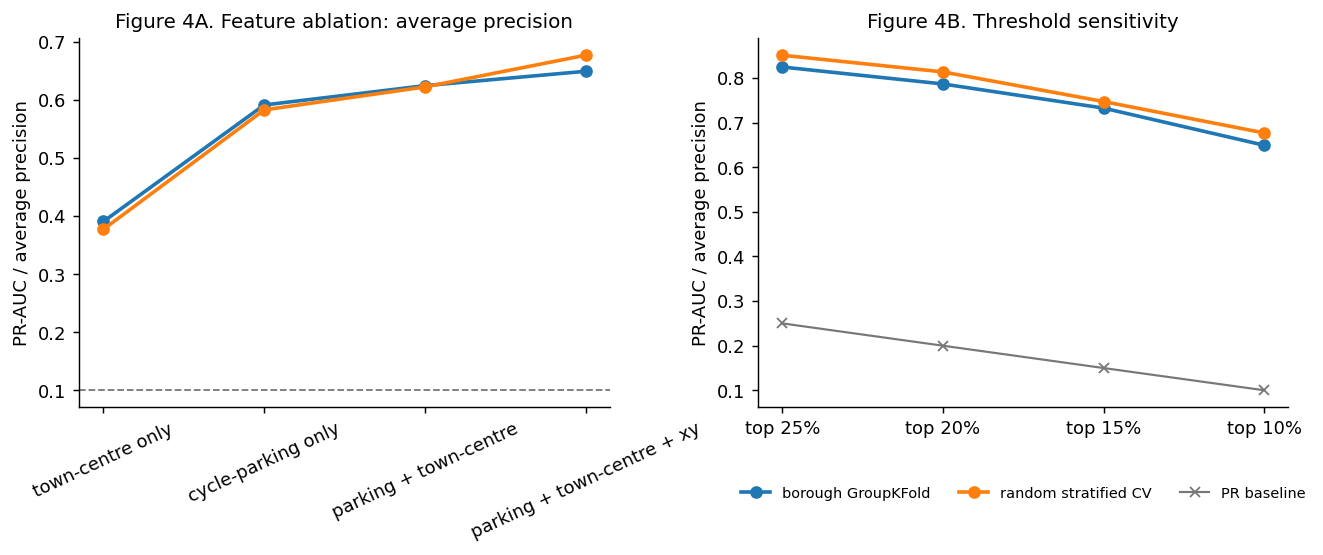

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for validation, group in ablation.groupby("validation"):
    ordered = group.set_index("feature_set").loc[list(feature_sets.keys())].reset_index()
    axes[0].plot(ordered["feature_set"], ordered["avg_precision"], marker="o", lw=2, label=validation)
axes[0].axhline(y.mean(), color="#777777", ls="--", lw=1, label="PR baseline")
axes[0].set_title("Figure 4A. Feature ablation: average precision")
axes[0].set_ylabel("PR-AUC / average precision")
axes[0].tick_params(axis="x", rotation=25)

for validation, group in threshold_sensitivity.groupby("validation"):
    axes[1].plot(group["hotspot_definition"], group["avg_precision"], marker="o", lw=2, label=validation)
axes[1].plot(threshold_sensitivity.drop_duplicates("hotspot_definition")["hotspot_definition"],
             threshold_sensitivity.drop_duplicates("hotspot_definition")["positive_rate"],
             marker="x", lw=1.2, color="#777777", label="PR baseline")
axes[1].set_title("Figure 4B. Threshold sensitivity")
axes[1].set_ylabel("PR-AUC / average precision")
axes[1].legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)

plt.subplots_adjust(bottom=0.25, wspace=0.28)
plt.show()

The final random forest exceeds the no-skill PR-AUC baseline of 0.10. In Figure 4, the random-stratified line is the easier non-spatial validation, the borough GroupKFold line is the stricter spatial validation, and the grey baseline is hotspot prevalence. Borough validation lowers PR-AUC from 0.677 to 0.649; the coordinate-block result is similar at 0.638. Because coordinates are predictors, spatial validation reflects transfer to unseen geography plus some coordinate extrapolation. Ablation clarifies the mechanism: parking is stronger than town-centre context, while coordinates capture broader inner-outer structure. Denominator robustness addresses the Modifiable Areal Unit Problem (MAUP): theft density and parking density both divide by LSOA area. Adding `area_km2`, using raw parking counts with area, comparing a count-target model, and dropping parking-location density leave the main result intact. Because parking capacity and location density have rho = 0.973, separate logit odds ratios are not interpreted independently. Threshold sensitivity shows the result is not an artefact of the top-decile definition.

F1-optimised threshold from training data: 0.690
Held-out average precision: 0.717
                 precision    recall  f1-score   support

    not extreme       0.96      0.96      0.96      1349
extreme hotspot       0.66      0.65      0.66       150

       accuracy                           0.93      1499
      macro avg       0.81      0.81      0.81      1499
   weighted avg       0.93      0.93      0.93      1499



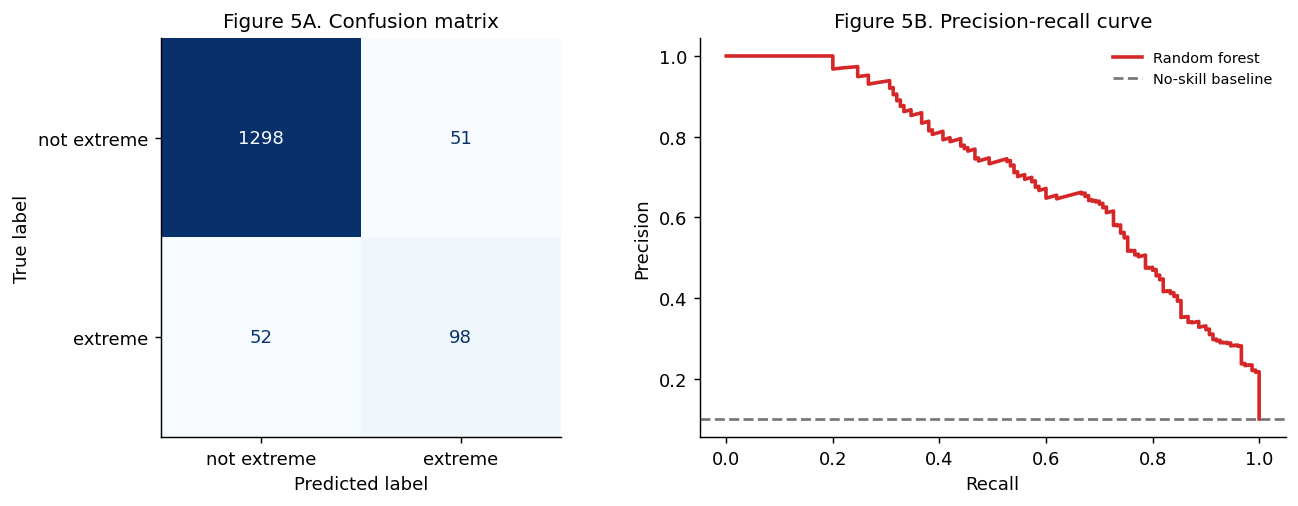

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.30, random_state=42, stratify=y)
rf = make_models()["Random forest"]
rf.fit(X_train, y_train)
test_scores = rf.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, rf.predict_proba(X_train)[:, 1])
f1_scores = (2 * precision * recall) / np.maximum(precision + recall, 1e-9)
best_threshold = thresholds[np.nanargmax(f1_scores[:-1])]
test_pred = (test_scores >= best_threshold).astype(int)

print(f"F1-optimised threshold from training data: {best_threshold:.3f}")
print(f"Held-out average precision: {average_precision_score(y_test, test_scores):.3f}")
print(classification_report(y_test, test_pred, target_names=["not extreme", "extreme hotspot"]))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["not extreme", "extreme"], cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Figure 5A. Confusion matrix")
pr_precision, pr_recall, _ = precision_recall_curve(y_test, test_scores)
axes[1].plot(pr_recall, pr_precision, color="#d62728", lw=2, label="Random forest")
axes[1].axhline(y_test.mean(), color="#777777", ls="--", label="No-skill baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Figure 5B. Precision-recall curve")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

Figure 5 is a diagnostic random holdout, not the main transferability claim. The red precision-recall curve shows the random forest's precision at each recall level; the grey dashed line is the no-skill baseline from hotspot prevalence. The curve staying well above the baseline means the model ranks hotspots usefully, while the confusion matrix still makes false positives and false negatives visible. The F1 threshold is selected from training predictions, so spatial CV and out-of-fold lift remain the more conservative performance evidence.

In [22]:
# Out-of-fold diagnostics use coordinate-grid spatial blocks so every probability
# is predicted from a model that did not train on that LSOA's local block.
oof_scores = np.zeros(len(analysis))
for train_idx, test_idx in GroupKFold(n_splits=5).split(X_final, y, groups=spatial_groups):
    fold_model = make_models()["Random forest"]
    fold_model.fit(X_final.iloc[train_idx], y.iloc[train_idx])
    oof_scores[test_idx] = fold_model.predict_proba(X_final.iloc[test_idx])[:, 1]
analysis["oof_hotspot_probability"] = oof_scores

lift = (
    analysis[["oof_hotspot_probability", "extreme_hotspot", "bike_theft_count"]]
    .sort_values("oof_hotspot_probability", ascending=False)
    .reset_index(drop=True)
)
lift["share_lsoas"] = (np.arange(len(lift)) + 1) / len(lift)
lift["captured_hotspots"] = lift["extreme_hotspot"].cumsum() / lift["extreme_hotspot"].sum()
lift["captured_thefts"] = lift["bike_theft_count"].cumsum() / lift["bike_theft_count"].sum()

lift_points = []
for share in [0.10, 0.20, 0.30]:
    row = lift.iloc[int(np.ceil(share * len(lift))) - 1]
    lift_points.append({
        "Top-ranked LSOAs": f"{int(share * 100)}%",
        "Hotspots captured": row["captured_hotspots"],
        "Thefts captured": row["captured_thefts"],
    })
display(pd.DataFrame(lift_points).round(3))

,Top-ranked LSOAs,Hotspots captured,Thefts captured
0,10%,0.624,0.392
1,20%,0.818,0.564
2,30%,0.898,0.674


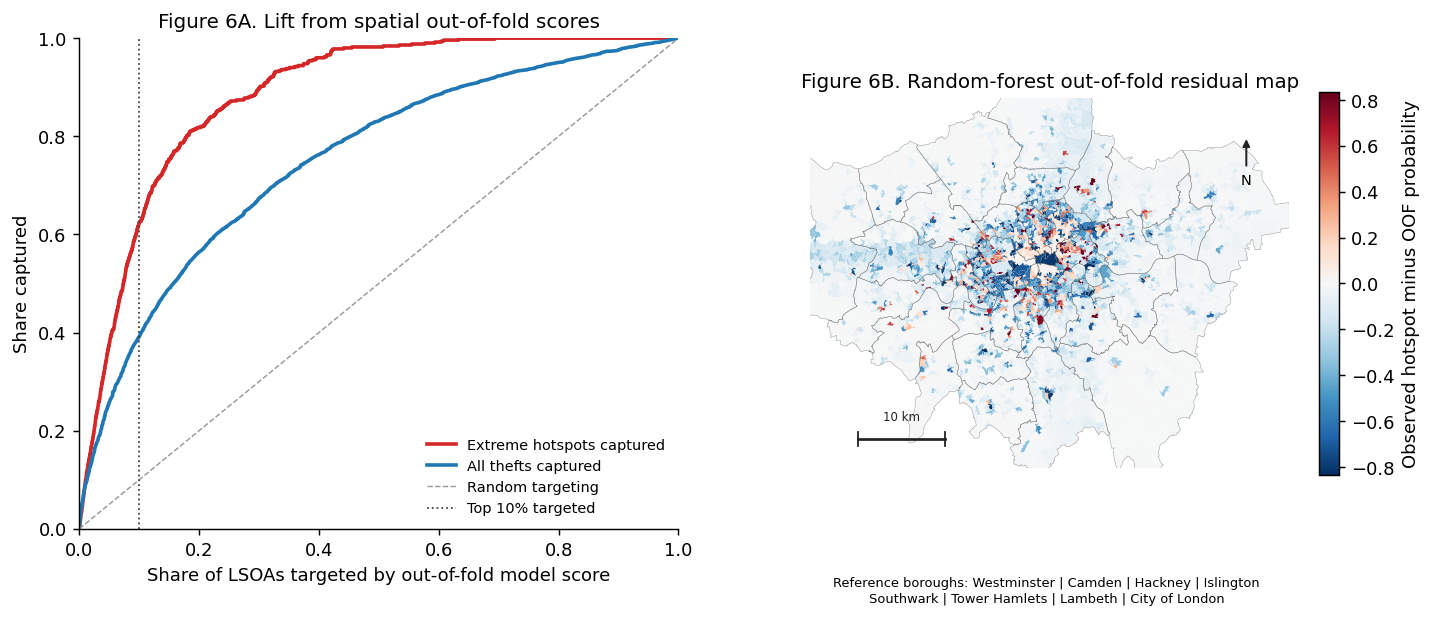

In [23]:
analysis["rf_oof_residual"] = analysis["extreme_hotspot"] - analysis["oof_hotspot_probability"]
hotspot_residuals = analysis.loc[analysis["extreme_hotspot"].eq(1), "rf_oof_residual"]
residual_threshold = hotspot_residuals.quantile(0.75)
analysis["residual_risk_hotspot"] = (
    analysis["extreme_hotspot"].eq(1)
    & analysis["rf_oof_residual"].ge(residual_threshold)
)

resid_limit = np.percentile(np.abs(analysis["rf_oof_residual"]), 98)
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.1))
axes[0].plot(lift["share_lsoas"], lift["captured_hotspots"], color="#d62728", lw=2, label="Extreme hotspots captured")
axes[0].plot(lift["share_lsoas"], lift["captured_thefts"], color="#1f77b4", lw=2, label="All thefts captured")
axes[0].plot([0, 1], [0, 1], color="#999999", lw=0.8, ls="--", label="Random targeting")
axes[0].axvline(0.10, color="#444444", lw=1, ls=":", label="Top 10% targeted")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Share of LSOAs targeted by out-of-fold model score")
axes[0].set_ylabel("Share captured")
axes[0].set_title("Figure 6A. Lift from spatial out-of-fold scores")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")

analysis.plot(
    column="rf_oof_residual",
    cmap="RdBu_r",
    vmin=-resid_limit,
    vmax=resid_limit,
    linewidth=0.02,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Observed hotspot minus OOF probability", "shrink": 0.78},
    ax=axes[1],
)
minx, miny, maxx, maxy = analysis.total_bounds
pad_x = 0.025 * (maxx - minx)
pad_y = 0.025 * (maxy - miny)
axes[1].set_xlim(minx + pad_x, maxx - pad_x)
axes[1].set_ylim(miny + pad_y, maxy - pad_y)
add_borough_context(
    axes[1],
    north=True,
    scale=True,
    north_xy=(0.91, 0.90),
    north_text=(0.91, 0.78),
    scale_xy=(0.12, 0.10),
)
axes[1].set_axis_off()
axes[1].set_title("Figure 6B. Random-forest out-of-fold residual map")
pos = axes[1].get_position()
fig.text(pos.x0 + pos.width / 2, 0.025, reference_borough_6b, ha="center", va="bottom", fontsize=7.2, linespacing=1.25)
plt.subplots_adjust(wspace=0.22, bottom=0.14)
plt.show()

,Feature,PR-AUC drop
0,Parking capacity density,0.2339
1,Parking location density,0.1552
2,Y coordinate,0.0996
3,X coordinate,0.0796
4,Town-centre share,0.0742
5,Town-centre area,0.0171
6,Town-centre pieces,0.0001


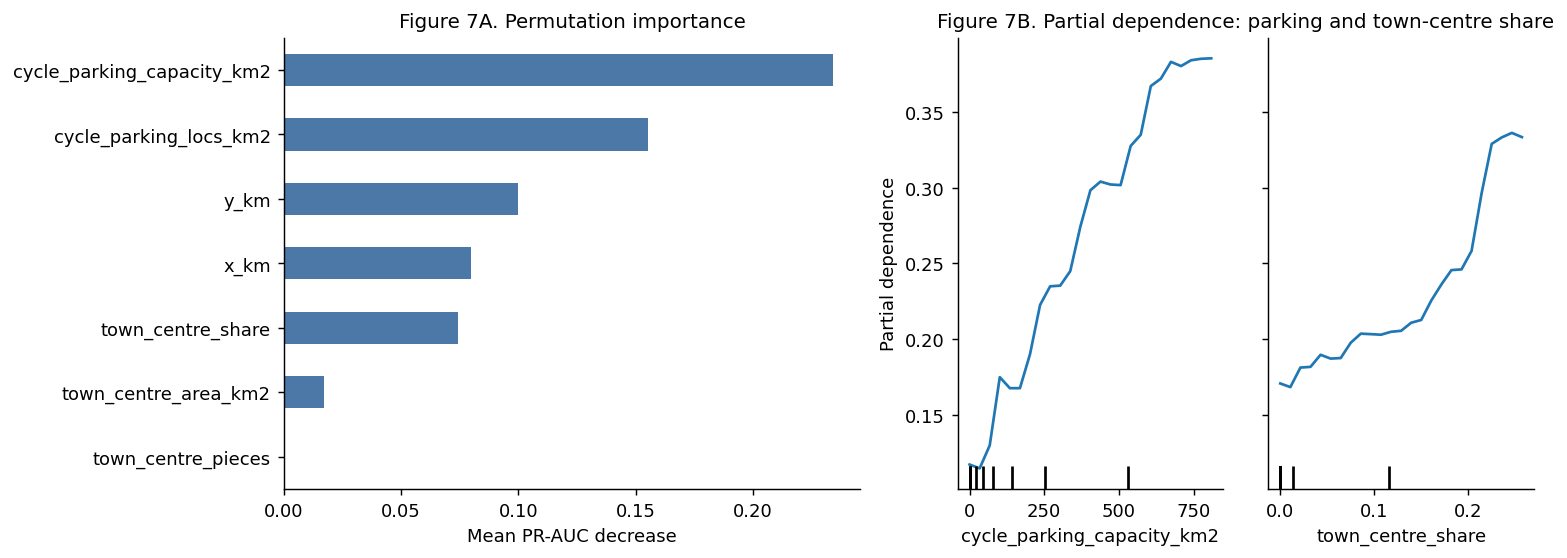

In [24]:
perm = permutation_importance(rf, X_test, y_test, scoring="average_precision", n_repeats=20, random_state=42, n_jobs=1)
perm_importance = pd.Series(perm.importances_mean, index=final_features).sort_values(ascending=False)
feature_labels = {
    "cycle_parking_capacity_km2": "Parking capacity density",
    "cycle_parking_locs_km2": "Parking location density",
    "town_centre_share": "Town-centre share",
    "town_centre_area_km2": "Town-centre area",
    "town_centre_pieces": "Town-centre pieces",
    "x_km": "X coordinate",
    "y_km": "Y coordinate",
}
perm_table = (
    perm_importance.rename_axis("Feature")
    .reset_index(name="PR-AUC drop")
    .replace({"Feature": feature_labels})
)
display(perm_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
perm_importance.sort_values().plot(kind="barh", ax=axes[0], color="#4c78a8")
axes[0].set_title("Figure 7A. Permutation importance")
axes[0].set_xlabel("Mean PR-AUC decrease")

PartialDependenceDisplay.from_estimator(
    rf,
    X_train,
    features=["cycle_parking_capacity_km2", "town_centre_share"],
    grid_resolution=25,
    ax=axes[1],
)
axes[1].set_title("Figure 7B. Partial dependence: parking and town-centre share")
plt.tight_layout()
plt.show()

Figure 7A asks which variables the random forest relies on most: a larger PR-AUC drop means model ranking worsens more when that feature is shuffled. This diagnostic uses the random held-out split, so it is read alongside spatial CV rather than as final transferability evidence. Figure 7B is a model-behaviour plot: each blue line shows how predicted hotspot probability changes as one feature varies while other features are averaged over. The small ticks on the x-axis show where observed values occur. This supports interpretation but is not causal evidence.

In [25]:
exposure_threshold = analysis["cycle_parking_capacity_km2"].quantile(0.75)
portfolio = analysis.copy()
portfolio["high_exposure"] = portfolio["cycle_parking_capacity_km2"] >= exposure_threshold
portfolio["priority_class"] = np.select(
    [
        portfolio["extreme_hotspot"].eq(1) & (~portfolio["high_exposure"] | portfolio["residual_risk_hotspot"]),
        portfolio["extreme_hotspot"].eq(1) & portfolio["high_exposure"],
        portfolio["extreme_hotspot"].eq(0) & portfolio["high_exposure"],
    ],
    ["residual-risk investigation", "secure-parking priority", "high-exposure prevention"],
    default="lower priority"
)
priority_order = ["residual-risk investigation", "secure-parking priority", "high-exposure prevention", "lower priority"]
portfolio["priority_class"] = pd.Categorical(portfolio["priority_class"], categories=priority_order, ordered=True)

portfolio_summary = (
    portfolio.groupby("priority_class", observed=True)
    .agg(lsoas=("lsoa21cd", "size"),
         bike_thefts=("bike_theft_count", "sum"),
         mean_theft_density=("bike_density_km2", "mean"),
         mean_parking_capacity_density=("cycle_parking_capacity_km2", "mean"),
         mean_rf_residual=("rf_oof_residual", "mean"))
    .reset_index()
)
portfolio_labels = {
    "secure-parking priority": "Secure parking",
    "residual-risk investigation": "Residual risk",
    "high-exposure prevention": "Prevention",
    "lower priority": "Lower",
}
portfolio_display = portfolio_summary.copy()
portfolio_display["priority_class"] = portfolio_display["priority_class"].astype(str).map(portfolio_labels)
portfolio_display = portfolio_display.rename(columns={
    "priority_class": "Class",
    "lsoas": "LSOAs",
    "bike_thefts": "Thefts",
    "mean_theft_density": "Mean theft density",
    "mean_parking_capacity_density": "Mean parking density",
    "mean_rf_residual": "Mean RF residual",
})
display(portfolio_display.round(2))

borough_priority = (
    portfolio[portfolio["priority_class"].eq("secure-parking priority")]
    .groupby("lad22nm")
    .agg(priority_lsoas=("lsoa21cd", "size"), bike_thefts=("bike_theft_count", "sum"))
    .sort_values(["priority_lsoas", "bike_thefts"], ascending=False)
    .head(10)
    .reset_index()
)
display(borough_priority.rename(columns={
    "lad22nm": "Borough",
    "priority_lsoas": "Priority LSOAs",
    "bike_thefts": "Thefts",
}))

name_col = "lsoa21nm" if "lsoa21nm" in portfolio.columns else "lsoa21cd"
priority_lsoas = (
    portfolio[portfolio["priority_class"].eq("secure-parking priority")]
    .sort_values("bike_density_km2", ascending=False)
    [[name_col, "lad22nm", "bike_theft_count", "bike_density_km2", "cycle_parking_capacity_km2"]]
    .head(10)
    .rename(columns={
        name_col: "LSOA",
        "lad22nm": "Borough",
        "bike_theft_count": "Thefts",
        "bike_density_km2": "Theft density",
        "cycle_parking_capacity_km2": "Parking density",
    })
)
display(priority_lsoas.round(2))

,Class,LSOAs,Thefts,Mean theft density,Mean parking density,Mean RF residual
0,Residual risk,125,2287.0,154.05,219.68,0.74
1,Secure parking,375,10848.0,212.63,908.52,0.19
2,Prevention,814,5972.0,49.12,450.86,-0.48
3,Lower,3680,9611.0,12.90,39.31,-0.06


,Borough,Priority LSOAs,Thefts
0,Hackney,65,1897.0
1,Southwark,43,1222.0
2,Tower Hamlets,39,1094.0
3,Westminster,38,1094.0
4,Islington,35,1000.0
5,Camden,34,1103.0
6,Lambeth,27,825.0
7,Hammersmith and Fulham,21,543.0
8,Wandsworth,13,315.0
9,Kensington and Chelsea,10,131.0


,LSOA,Borough,Thefts,Theft density,Parking density
3177,Lambeth 004J,Lambeth,50.0,1214.74,2040.76
1891,Hackney 025H,Hackney,107.0,1098.79,657.22
4444,Tower Hamlets 021I,Tower Hamlets,22.0,814.38,592.27
1904,Hackney 030A,Hackney,72.0,764.16,2441.08
1905,Hackney 023G,Hackney,115.0,708.31,1903.19
1889,Hackney 030B,Hackney,77.0,699.32,1870.90
4524,Tower Hamlets 013C,Tower Hamlets,112.0,691.90,407.73
1913,Hackney 033A,Hackney,99.0,642.25,1556.96
4117,Southwark 009H,Southwark,36.0,627.57,2440.55
4726,Wandsworth 018F,Wandsworth,37.0,612.49,893.90


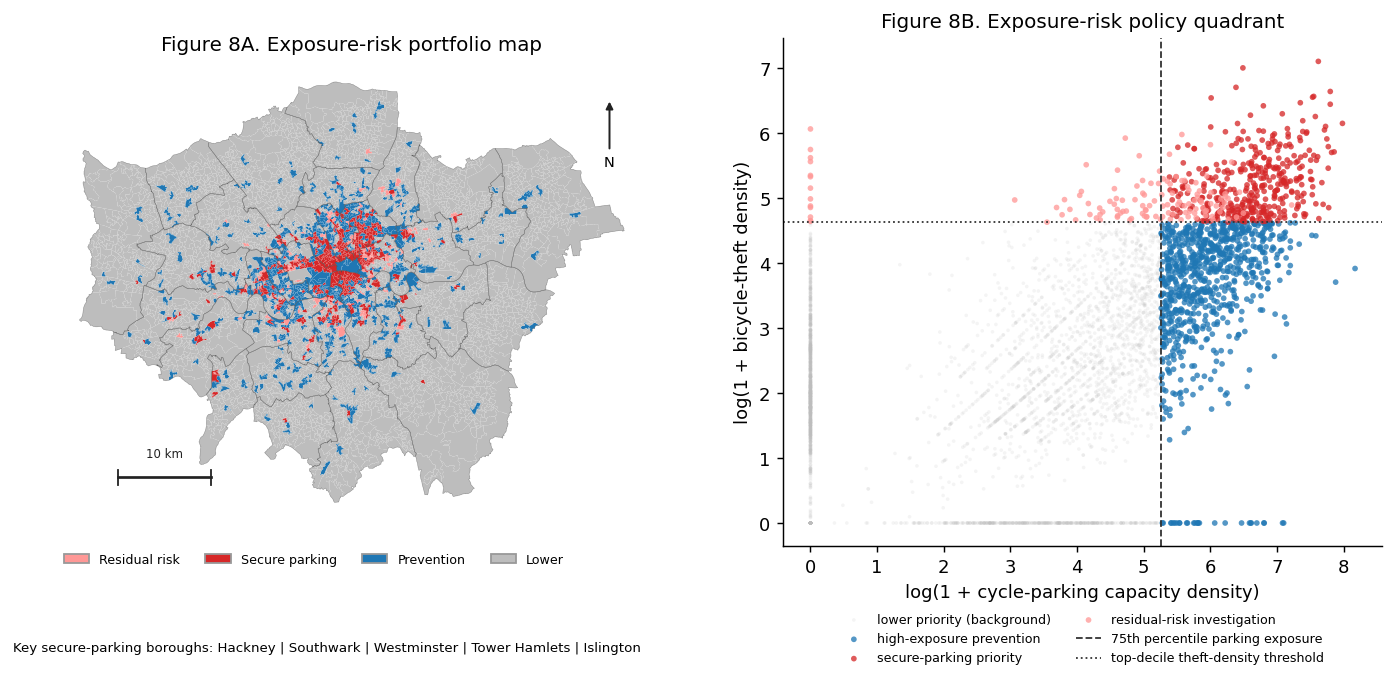

In [26]:
colors = {
    "secure-parking priority": "#d62728",
    "residual-risk investigation": "#ff9896",
    "high-exposure prevention": "#1f77b4",
    "lower priority": "#bdbdbd",
}
fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.2))
portfolio.plot(color=portfolio["priority_class"].map(colors), linewidth=0.02, edgecolor="white", ax=axes[0])
add_borough_context(axes[0], north=True, scale=True)
axes[0].set_axis_off()
axes[0].set_title("Figure 8A. Exposure-risk portfolio map")
map_legend_handles = [Patch(facecolor=colors[cls], edgecolor="#999999", label=portfolio_labels.get(cls, cls)) for cls in priority_order]
axes[0].legend(handles=map_legend_handles, frameon=False, fontsize=7, loc="upper left", bbox_to_anchor=(0, -0.04), ncol=4)

for cls in priority_order[::-1]:
    sub = portfolio[portfolio["priority_class"].eq(cls)]
    label = "lower priority (background)" if cls == "lower priority" else cls
    axes[1].scatter(
        np.log1p(sub["cycle_parking_capacity_km2"]),
        np.log1p(sub["bike_density_km2"]),
        s=10 if cls != "lower priority" else 4,
        alpha=0.76 if cls != "lower priority" else 0.16,
        color=colors[cls],
        label=label,
        edgecolors="none",
    )
axes[1].axvline(np.log1p(exposure_threshold), color="#333333", lw=1, ls="--", label="75th percentile parking exposure")
axes[1].axhline(np.log1p(hotspot_threshold), color="#333333", lw=1, ls=":", label="top-decile theft-density threshold")
axes[1].set_xlabel("log(1 + cycle-parking capacity density)")
axes[1].set_ylabel("log(1 + bicycle-theft density)")
axes[1].set_title("Figure 8B. Exposure-risk policy quadrant")
axes[1].legend(frameon=False, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=2)
fig.text(0.285, 0.115, portfolio_key_areas, ha="center", va="bottom", fontsize=7.4)
plt.subplots_adjust(bottom=0.25, wspace=0.22)
plt.show()

The spatial out-of-fold lift curve shifts evaluation from accuracy to intervention value: high-scored LSOAs capture far more hotspots than random targeting. The residual map uses the same random forest: positive values mark observed hotspots under-predicted by the spatial out-of-fold model.

Permutation importance confirms that random forest mainly uses cycle-parking density and broad spatial location, while town-centre context adds a smaller activity-centre signal. Because parking capacity and parking-location density are highly correlated, importance and partial-dependence plots are interpreted as model behaviour, not isolated causal effects or calibrated risk probabilities.

The portfolio translates the model into a prioritisation aid, not intervention proof. Secure-parking priority LSOAs combine extreme theft density with high parking exposure. Residual-risk investigation areas are hotspots with lower public-parking exposure or unexpectedly low model probability, suggesting private parking, residential theft, guardianship or unobserved activity. High-exposure prevention areas are useful comparators. In Figure 8B the grey points are lower-priority LSOAs kept as a background distribution so the three priority classes can be read against the full London pattern.

## Conclusion
[[ go back to the top ]](#Table-of-contents)

RQ1: bicycle theft is highly concentrated; top-decile density hotspots contain 45.7% of recorded thefts. RQ2: cycle-parking density provides the strongest exposure signal, with town-centre context and broad geography adding smaller but useful information. RQ3: the final random forest remains above baseline under spatial validation, reaching borough PR-AUC 0.649 and coordinate-block PR-AUC 0.638 against 0.100, but this is predictive evidence only.

RQ4: the exposure-risk portfolio operationalises the model as a screening tool. The top 10% model-ranked LSOAs capture 62.4% of hotspots and 39.2% of thefts, and the portfolio separates secure-parking priorities from residual-risk investigation areas and high-exposure non-hotspots. The main limitations are cross-sectional timing, shared area denominators, correlated parking variables and missing exposure/security measures. Cycle-parking capacity is therefore an exposure signal within a model that also includes broad spatial geography, not evidence that parking provision causes theft. Future work should add footfall, cycling-flow, POI and parking-security data.

## References
[[ go back to the top ]](#Table-of-contents)

Brantingham, P. L. and Brantingham, P. J. (1995). Criminality of place: Crime generators and crime attractors. *European Journal on Criminal Policy and Research*, 3, 5-26. https://doi.org/10.1007/BF02242925

Cohen, L. E. and Felson, M. (1979). Social change and crime rate trends: A routine activity approach. *American Sociological Review*, 44(4), 588-608. https://doi.org/10.2307/2094589

Greater London Authority. Recorded Crime: Geographic Breakdown. London Datastore. Accessed 2026-05-04. https://data.london.gov.uk/dataset/recorded_crime_summary

Greater London Authority. Statistical GIS Boundary Files for London: LSOA 2021 boundaries. London Datastore. Accessed 2026-05-04. https://data.london.gov.uk/dataset/statistical-gis-boundary-files-london

Greater London Authority. London town centre boundaries. London Datastore / ArcGIS REST service. Accessed 2026-05-04. https://gis.london.gov.uk/arcgis/rest/services/apps/planning_data_map_02/MapServer/104

Ito, Y., Morgan, M. and Lovelace, R. (2023). Where to invest in cycle parking: A portfolio management approach to spatial transport planning. *Environment and Planning B: Urban Analytics and City Science*, 50(6), 1438-1454. https://doi.org/10.1177/23998083221138575

Johnson, S. D., Sidebottom, A. and Thorpe, A. (2008). *Bicycle theft*. Problem-Oriented Guides for Police, Problem-Specific Guides Series No. 52. Washington, DC: U.S. Department of Justice, Office of Community Oriented Policing Services. https://popcenter.asu.edu/content/bicycle-theft-0

Mburu, L. W. and Helbich, M. (2016). Environmental risk factors influencing bicycle theft: A spatial analysis in London, UK. *PLOS ONE*, 11(9), e0163354. https://doi.org/10.1371/journal.pone.0163354

Sidebottom, A., Thorpe, A. and Johnson, S. D. (2009). Using targeted publicity to reduce opportunities for bicycle theft: A demonstration and replication. *European Journal of Criminology*, 6(3), 267-286. https://doi.org/10.1177/1477370809102168

Strobl, C., Boulesteix, A.-L., Zeileis, A. and Hothorn, T. (2007). Bias in random forest variable importance measures: illustrations, sources and a solution. *BMC Bioinformatics*, 8, 25. https://doi.org/10.1186/1471-2105-8-25

Transport for London. Cycling Infrastructure Database: cycle parking points. Accessed 2026-05-04. https://cycling.data.tfl.gov.uk/